In [ ]:
from google.colab import files

# Upload feature table and metadata TSVs
uploaded = files.upload()

Saving metadata_final_final.tsv to metadata_final_final.tsv
Saving feature_table_no_bios_final.tsv to feature_table_no_bios_final.tsv


In [ ]:
# Step 1 — Import packages and load uploaded files
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import make_scorer, recall_score

sns.set(style="whitegrid")
print("Ready.")

Ready.


In [ ]:
# CELL 1 — Load the dataset
# We load two files:
# feature_table_no_bios_final.tsv  → bacteria counts per sample (our X)
# metadata_final_final.tsv       → which group each sample belongs to (our y)

feature_file = "feature_table_no_bios_final.tsv"
metadata_file = "metadata_final_final.tsv"

# Read the file as a dataframe
X_raw = pd.read_csv(feature_file, sep="\t",index_col=0)

# Read the file as a dataframe
metadata = pd.read_csv(metadata_file, sep="\t", index_col=0)

# Merge so X and y are aligned on the same sample IDs
data = X_raw.join(metadata)



In [ ]:
label_col = "group"
y_all = data[label_col]
X_all = data.drop(columns=[label_col])

# Make sure everything is numeric; fill any missing values with 0
X_all = X_all.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Dataset shape:", X_all.shape)
print("\nSamples per group:")
print(y_all.value_counts())

Dataset shape: (239, 205)

Samples per group:
group
OSCC    183
Heal     39
PMaD     17
Name: count, dtype: int64


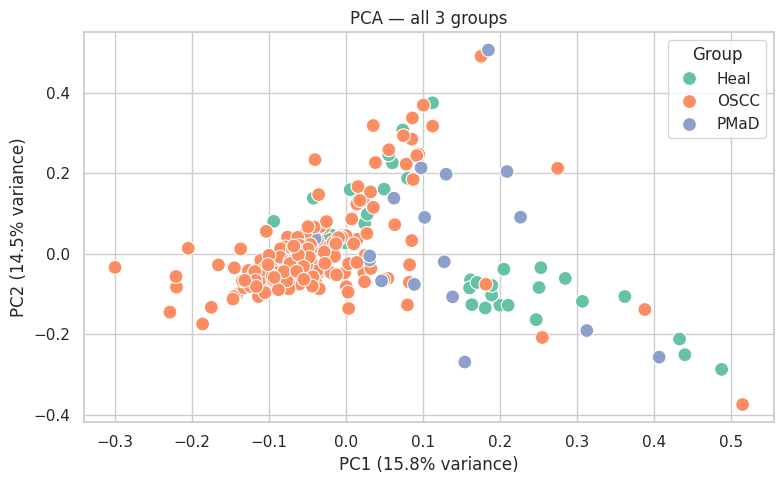

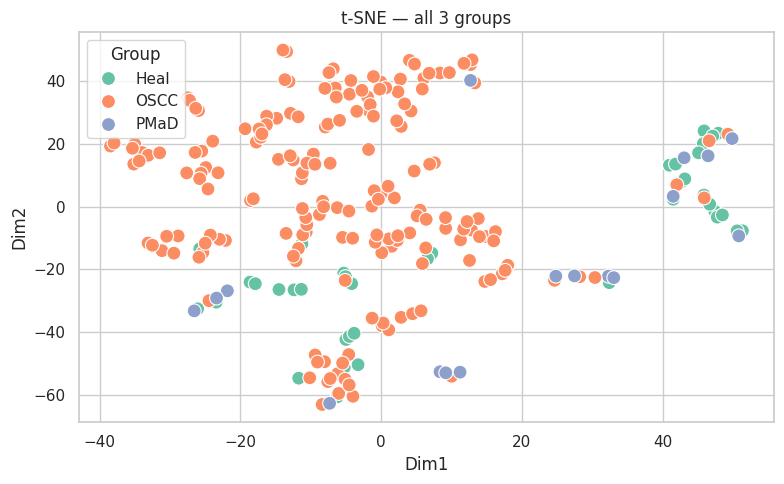

In [ ]:
# CELL 2 — Normalise and explore the data
# We convert raw counts to relative abundance (each sample sums to 1).
# Then we plot PCA and t-SNE to see if the 5 groups look separable

# --- Relative abundance normalisation ---
X_norm = X_all.div(X_all.sum(axis=1), axis=0)

# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_norm.index)
pca_df["group"] = y_all.values

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="group", s=100, palette="Set2")
plt.title("PCA — all 3 groups")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

# --- t-SNE ---
perp = min(5, len(X_norm) - 1)  # safe perplexity for small datasets
tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
X_tsne = tsne.fit_transform(X_norm)
tsne_df = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"], index=X_norm.index)
tsne_df["group"] = y_all.values

plt.figure(figsize=(8, 5))
sns.scatterplot(data=tsne_df, x="Dim1", y="Dim2", hue="group", s=100, palette="Set2")
plt.title("t-SNE — all 3 groups")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

## === EXPERIMENT 1: 5-CLASS CLASSIFICATION ===

In [ ]:
# Since we are using repated stratifed k fold, the best way to evaluate the model is with averaged prediction

def get_averaged_predictions(model, X, y, n_splits=5, n_repeats=10, random_state=42):
    n_samples = len(y)
    classes = np.unique(y)
    n_classes = len(classes)

    proba_sum = np.zeros((n_samples, n_classes))


    y_arr = y.values if hasattr(y, "values") else y

    for repeat in range(n_repeats):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state + repeat)
        proba_repeat = np.zeros((n_samples, n_classes))

        for train_idx, test_idx in cv.split(X, y_arr):
            X_train = X.iloc[train_idx]
            X_test  = X.iloc[test_idx]
            y_train = y_arr[train_idx]

            model.fit(X_train, y_train)
            proba_repeat[test_idx] = model.predict_proba(X_test)

        proba_sum += proba_repeat

    proba_avg = proba_sum / n_repeats
    preds_idx = np.argmax(proba_avg, axis=1)
    preds = classes[preds_idx]

    return preds, proba_avg

In [ ]:
#

def evaluate_model(model, X, y, model_name, class_order=None):

    # 1. Determine correct class names
    if class_order is not None:
        classes = np.array(class_order)
    else:
        # If y is numeric (encoded), use unique sorted ints
        if isinstance(y, np.ndarray):
            classes = np.unique(y)
        else:
            classes = np.array(sorted(y.unique()))

    if np.issubdtype(classes.dtype, np.number):
        target_names = [str(c) for c in classes]
    else:
        target_names = list(classes)


    # 2. Cross-validation.
    # We are running repeated stratified k-fold cv 5 folds repeated 10 times.
    # We track accuracy and macro-F1 on the test set each round


    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

    cv_results = cross_validate(
        model, X, y, cv=cv,
        scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
        return_train_score=False,
        n_jobs=-1
    )

    # Summarise the 50 scores into a mean ± std for each metric
    cv_acc     = cv_results["test_accuracy"].mean()
    cv_acc_std = cv_results["test_accuracy"].std()
    cv_f1      = cv_results["test_f1_macro"].mean()
    cv_f1_std  = cv_results["test_f1_macro"].std()

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  CV Accuracy:  {cv_results['test_accuracy'].mean():.3f} "
          f"(+/- {cv_results['test_accuracy'].std():.3f})")
    print(f"  CV Macro F1:  {cv_results['test_f1_macro'].mean():.3f} "
          f"(+/- {cv_results['test_f1_macro'].std():.3f})")


    # 3. Train/test split

    # Averaged predictions across repeats for confusion matrix + AUC
    preds, proba_avg = get_averaged_predictions(model, X, y)


    # 4. Classification report

    print("\n  Classification report:")
    print(classification_report(y, preds, target_names=target_names))

    # 5. AUC (robust multi-class handling)

    auc = "N/A"
    if hasattr(model, "predict_proba"):
        if len(classes) == 2:
            auc = roc_auc_score(y, proba_avg[:, 1])
        else:
            auc = roc_auc_score(y, proba_avg, multi_class="ovr", average="macro")
        print(f"  AUC: {auc:.3f}")


    # 6. Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y, preds,
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"Confusion matrix — {model_name}\n(aggregated CV predictions, n={len(y)})")
    plt.tight_layout()
    plt.show()

    metrics = {
        "Model":       model_name,
        "CV Accuracy": f"{cv_acc:.3f} ± {cv_acc_std*2:.3f}",
        "CV Macro F1": f"{cv_f1:.3f} ± {cv_f1_std*2:.3f}",
        "AUC":         f"{auc:.3f}" if isinstance(auc, float) else auc
    }

    return model, metrics

Best C (L2): {'clf__C': 0.001}

  Logistic Regression L2 — 3 class
  CV Accuracy:  0.780 (+/- 0.043)
  CV Macro F1:  0.610 (+/- 0.070)

  Classification report:
              precision    recall  f1-score   support

        Heal       0.68      0.49      0.57        39
        OSCC       0.97      0.83      0.90       183
        PMaD       0.24      0.76      0.36        17

    accuracy                           0.77       239
   macro avg       0.63      0.69      0.61       239
weighted avg       0.87      0.77      0.80       239

  AUC: 0.916


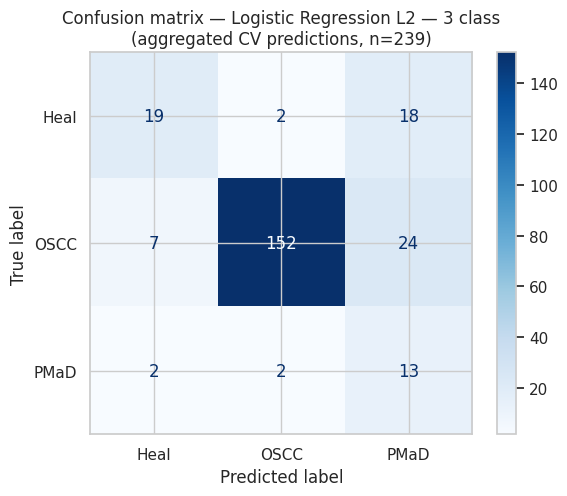

In [ ]:
# CELL 4 — Logistic Regression on all 3 groups
# Logistic Regression is a simple, interpretable classifier.
# 'balanced' class weight compensates for unequal group sizes.
# Its coefficients tell us which bacteria matter most.


#L2 lbfgs optimize for performance

lr_l2_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_l2_grid = GridSearchCV(
    lr_l2_pipeline,
    param_grid={"clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=cv_tune,
    scoring="f1_macro",
    n_jobs=-1
)
lr_l2_grid.fit(X_norm, y_all)
print("Best C (L2):", lr_l2_grid.best_params_)

lr_l2_fitted, lr_l2_metrics = evaluate_model(
    lr_l2_grid.best_estimator_, X_norm, y_all, "Logistic Regression L2 — 3 class"
)


Best C (L1): {'clf__C': 0.1}

  Logistic Regression L1 — 3 class
  CV Accuracy:  0.801 (+/- 0.047)
  CV Macro F1:  0.603 (+/- 0.090)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



  Classification report:
              precision    recall  f1-score   support

        Heal       0.69      0.69      0.69        39
        OSCC       0.96      0.89      0.92       183
        PMaD       0.29      0.53      0.38        17

    accuracy                           0.83       239
   macro avg       0.65      0.70      0.66       239
weighted avg       0.87      0.83      0.84       239

  AUC: 0.881


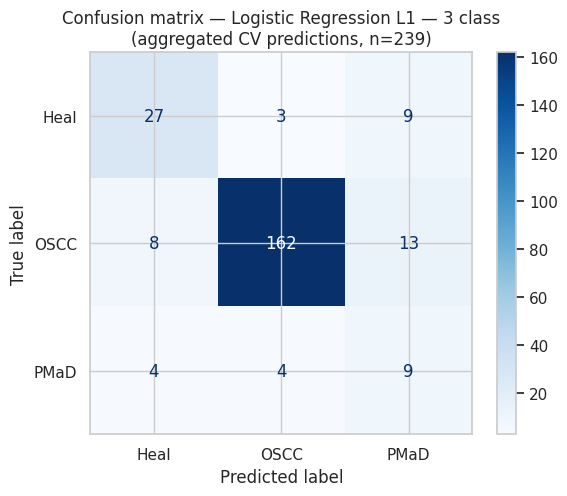

In [ ]:
#L1 sparse see which one is the most important one

lr_l1_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_l1_grid = GridSearchCV(
    lr_l1_pipeline,
    param_grid={"clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=cv_tune,
    scoring="f1_macro",
    n_jobs=-1
)
lr_l1_grid.fit(X_norm, y_all)
print("Best C (L1):", lr_l1_grid.best_params_)

lr_l1_fitted, lr_l1_metrics = evaluate_model(
    lr_l1_grid.best_estimator_, X_norm, y_all, "Logistic Regression L1 — 3 class"
)

In [ ]:
# get the pipeline directly from the grid search
l1_pipeline = lr_l1_grid.best_estimator_
l1_coef = l1_pipeline.named_steps["clf"].coef_

n_nonzero = (l1_coef != 0).sum(axis=1)
print(" L1 Non-zero ASVs per class:", n_nonzero)
print(f"L1 Total ASVs selected: {(l1_coef.any(axis=0)).sum()} out of {l1_coef.shape[1]}")


l2_pipeline = lr_l2_grid.best_estimator_
l2_coef = l2_pipeline.named_steps["clf"].coef_

n_nonzero = (l2_coef != 0).sum(axis=1)
print("L2 Non-zero ASVs per class:", n_nonzero)
print(f"L1 Total ASVs selected: {(l2_coef.any(axis=0)).sum()} out of {l2_coef.shape[1]}")

 L1 Non-zero ASVs per class: [20 11  3]
L1 Total ASVs selected: 29 out of 205
L2 Non-zero ASVs per class: [192 192 192]
L1 Total ASVs selected: 192 out of 205


The above result is telling us that L1 only needed 29 unique ASV out of 205 total (86% discarded as noise). PMaD is using 3 ASV's that matter for classification. L2 uses 192 which is almost everything and that's not being efficiant

In [ ]:
l1_pipeline = lr_l1_grid.best_estimator_
l1_coef = l1_pipeline.named_steps["clf"].coef_
feature_names = X_norm.columns.tolist()
classes = lr_l1_grid.best_estimator_.named_steps["clf"].classes_

for i, cls in enumerate(classes):
    nonzero_idx = np.where(l1_coef[i] != 0)[0]
    print(f"\n{cls} — {len(nonzero_idx)} ASVs:")
    for idx in nonzero_idx:
        print( "The most important ones of each class are:")
        print(f" {feature_names[idx]:30s}  coef={l1_coef[i, idx]:.4f}")


Heal — 20 ASVs:
The most important ones of each class are:
 k__Bacteria;p__Acidobacteria;c__Solibacteres;o__Solibacterales;f__Solibacteraceae;g__  coef=0.0185
The most important ones of each class are:
 k__Bacteria;p__Actinobacteria;c__Coriobacteriia;o__Coriobacteriales;f__Coriobacteriaceae;g__  coef=0.0707
The most important ones of each class are:
 k__Bacteria;p__Bacteroidetes;c__Flavobacteriia;o__Flavobacteriales;f__[Weeksellaceae];g__  coef=0.1467
The most important ones of each class are:
 k__Bacteria;p__Firmicutes;c__Bacilli;o__Gemellales;f__Gemellaceae;g__Gemella  coef=0.0151
The most important ones of each class are:
 k__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Granulicatella  coef=-0.1719
The most important ones of each class are:
 k__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__  coef=0.5561
The most important ones of each class are:
 k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Lachnospiraceae

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 4, 'clf__n_estimators': 500}
Best CV F1: 0.7908558606491052

  Random Forest — 3 class
  CV Accuracy:  0.864 (+/- 0.048)
  CV Macro F1:  0.735 (+/- 0.081)

  Classification report:
              precision    recall  f1-score   support

        Heal       0.65      0.90      0.75        39
        OSCC       0.94      0.89      0.92       183
        PMaD       0.50      0.35      0.41        17

    accuracy                           0.85       239
   macro avg       0.70      0.71      0.69       239
weighted avg       0.86      0.85      0.85       239

  AUC: 0.950


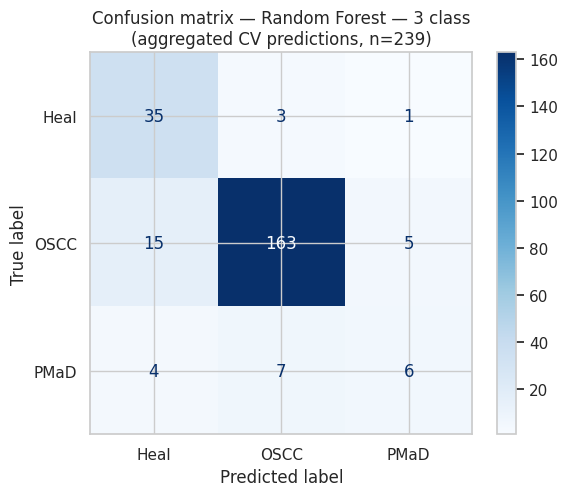

In [ ]:
# CELL 5 — Random Forest on all 5 groups
# Random Forest builds many decision trees and combines them.
# It handles non-linear patterns and is robust to noise.
# No scaling needed, but we include it for consistency.

rf_pipeline = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid={
        "clf__n_estimators":     [200, 300, 500],
        "clf__max_features":     ["sqrt", "log2", 0.3],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_depth":        [None, 10, 20]
    },
    cv=cv_tune,
    scoring="f1_macro",
    n_jobs=-1,
    verbose = 1
)

rf_grid.fit(X_norm, y_all)
print("Best params:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

rf_fitted, rf_metrics = evaluate_model(
    rf_grid.best_estimator_, X_norm, y_all, "Random Forest — 3 class"
)

/tmp/ipykernel_1839/4181831105.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


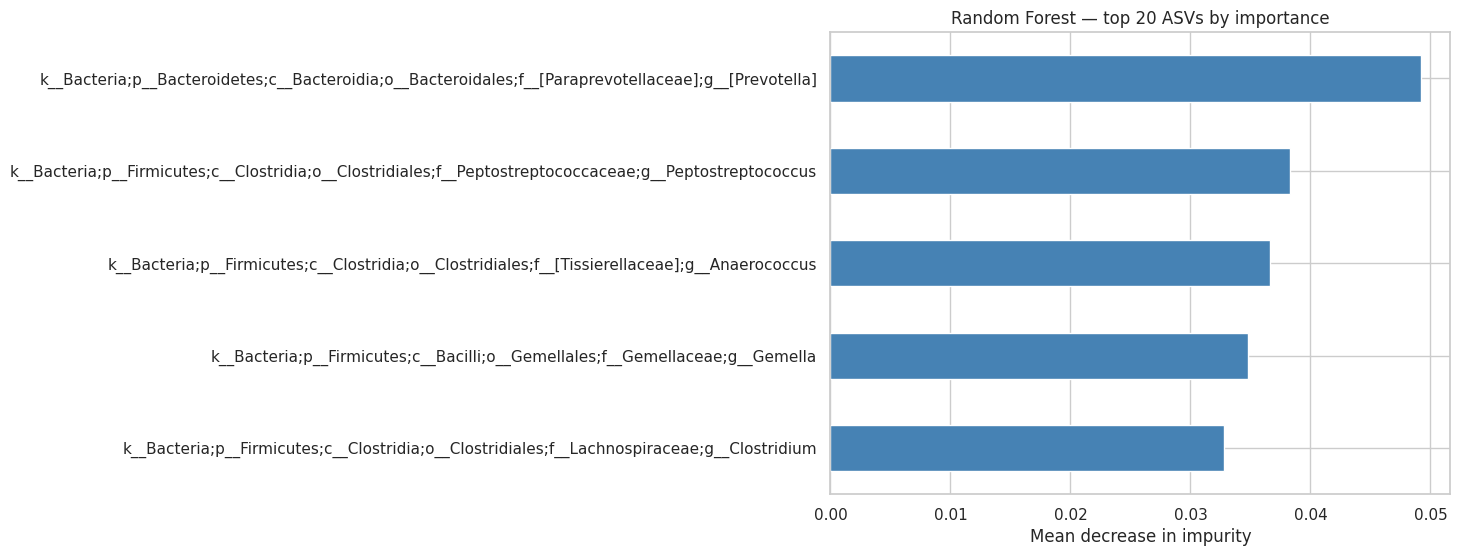

In [ ]:
# We want to know which ASV where most immportant for PMaD

rf_best = rf_grid.best_estimator_.named_steps["clf"]
feature_names = X_norm.columns.tolist()

importances = pd.Series(rf_best.feature_importances_, index=feature_names)
top5 = importances.nlargest(5)

plt.figure(figsize=(8, 6))
top5.sort_values().plot(kind="barh", color="steelblue")
plt.title("Random Forest — top 20 ASVs by importance")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

Sample column names: ['k__Bacteria;p__Acidobacteria;c__Solibacteres;o__Solibacterales;f__Solibacteraceae;g__', 'k__Bacteria;p__Actinobacteria;c__Acidimicrobiia;o__Acidimicrobiales;f__Iamiaceae;g__Iamia', 'k__Bacteria;p__Actinobacteria;c__Actinobacteria;o__Actinomycetales;f__ACK-M1;g__']
Label mapping: {'Heal': np.int64(0), 'OSCC': np.int64(1), 'PMaD': np.int64(2)}
Fitting 15 folds for each of 243 candidates, totalling 3645 fits
Best params: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 500, 'clf__subsample': 0.7}
Best CV F1: 0.7542092215222357

  XGBoost — 3 class
  CV Accuracy:  0.873 (+/- 0.035)
  CV Macro F1:  0.675 (+/- 0.097)

  Classification report:
              precision    recall  f1-score   support

        Heal       0.77      0.85      0.80        39
        OSCC       0.93      0.95      0.94       183
        PMaD       0.62      0.29      0.40        17

    accuracy                           0.89       239
   macro

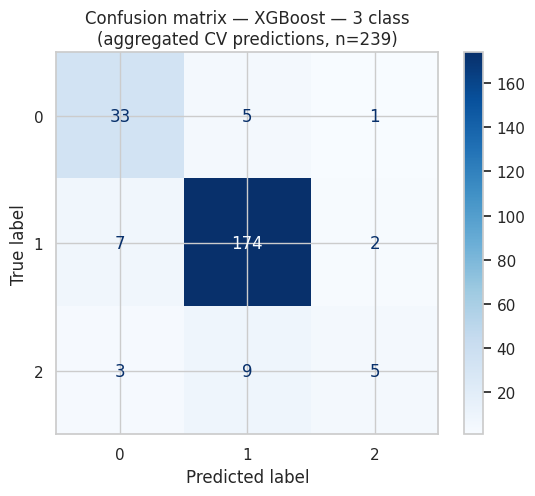

'# Note: we pass y_encoded here instead of y_all\nxgb_fitted = evaluate_model(xgb_pipeline, X_norm, y_encoded, "XGBoost — 3 class")'

In [ ]:
# CELL 6 — XGBoost on all 3 groups
# XGBoost builds trees sequentially, each one correcting the
# errors of the last. Often the strongest performer.
# We encode labels as integers because XGBoost requires it.

# compute class weights to pass as sample_weight

# clean feature names — remove characters XGBoost doesn't allow
X_norm_xgb = X_norm.copy()
X_norm_xgb.columns = (
    X_norm_xgb.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
)

# verify no bad characters remain
print("Sample column names:", X_norm_xgb.columns[:3].tolist())

le = LabelEncoder()
y_encoded = le.fit_transform(y_all)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

sample_weights = compute_sample_weight(class_weight="balanced", y=y_encoded)

xgb_pipeline = Pipeline([
    ("clf", XGBClassifier(
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

cv_tune = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

xgb_grid = GridSearchCV(
    xgb_pipeline,
    param_grid={
        "clf__n_estimators":   [200, 300, 500],
        "clf__learning_rate":  [0.01, 0.05, 0.1],
        "clf__max_depth":      [3, 4, 6],
        "clf__subsample":      [0.7, 0.8, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 1.0]
    },
    cv=cv_tune,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

# pass sample weights via fit_params
xgb_grid.fit(X_norm_xgb, y_encoded, clf__sample_weight=sample_weights)

print("Best params:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)


xgb_fitted = evaluate_model(
    xgb_grid.best_estimator_, X_norm_xgb, y_encoded,
    "XGBoost — 3 class", class_order=list(le.classes_)
)
"""# Note: we pass y_encoded here instead of y_all
xgb_fitted = evaluate_model(xgb_pipeline, X_norm, y_encoded, "XGBoost — 3 class")"""

In [ ]:
# ============================================================
# CELL 7 — Which bacteria drive the classification?
# ------------------------------------------------------------
# Each model has a different way of measuring importance:
#   Logistic Regression → coefficients (one per class per ASV)
#   Random Forest       → mean decrease in impurity
#   XGBoost             → gain-based feature importance
# We plot the top 20 ASVs for Random Forest and LR here.
# ============================================================

top_n = 5

# Random Forest
rf_clf = rf_grid.best_estimator_.named_steps["clf"]
rf_top = pd.Series(rf_clf.feature_importances_, index=feature_names).nlargest(top_n)
print("RF top 5:")
print(rf_top)

# Logistic Regression L1
lr_clf = lr_l1_grid.best_estimator_.named_steps["clf"]
lr_top = pd.Series(np.abs(lr_clf.coef_).mean(axis=0), index=feature_names).nlargest(top_n)
print("\nLR L1 top 5:")
print(lr_top)

# XGBoost
xgb_clf = xgb_grid.best_estimator_.named_steps["clf"]
feature_names_xgb = X_norm_xgb.columns.tolist()
xgb_top = pd.Series(xgb_clf.feature_importances_, index=feature_names_xgb).nlargest(top_n)
print("\nXGBoost top 5:")
print(xgb_top)

RF top 5:
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__[Paraprevotellaceae];g__[Prevotella]       0.049207
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Peptostreptococcaceae;g__Peptostreptococcus    0.038277
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__[Tissierellaceae];g__Anaerococcus              0.036670
k__Bacteria;p__Firmicutes;c__Bacilli;o__Gemellales;f__Gemellaceae;g__Gemella                               0.034830
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Lachnospiraceae;g__Clostridium                 0.032797
dtype: float64

LR L1 top 5:
k__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Pasteurellales;f__Pasteurellaceae;__            0.275080
k__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__                         0.185383
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Porphyromonadaceae;g__Porphyromonas     0.174673
k__Bacteria;p__Actinobacteria;c__Actinobac

# EXPERIMENT 2a: Leave OSCC out (BINARY EARLY DETECTION)

In [ ]:
# ============================================================
# EXPERIMENT 2: Leave-OSCC-out — can a Heal/PMaD model
# recognise OSCC without ever having seen it?
# ------------------------------------------------------------
# We train on Heal + PMaD only, then apply to OSCC samples.
# If OSCC gets predicted as PMaD → microbiome changes before
# cancer forms and persists through disease progression.
# ============================================================

# ============================================================
# EXPERIMENT 2 — CELL 1: Split data
# ============================================================

mask_train = y_all.isin(["Heal", "PMaD"])
mask_oscc  = y_all == "OSCC"

X_train_exp2 = X_norm[mask_train]
y_train_exp2 = y_all[mask_train]

X_oscc = X_norm[mask_oscc]
y_oscc = y_all[mask_oscc]

# XGBoost needs cleaned column names
X_train_exp2_xgb = X_train_exp2.copy()
X_train_exp2_xgb.columns = (
    X_train_exp2_xgb.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
)
X_oscc_xgb = X_oscc.copy()
X_oscc_xgb.columns = X_train_exp2_xgb.columns

# encode labels for XGBoost
le_exp2 = LabelEncoder()
y_train_exp2_enc = le_exp2.fit_transform(y_train_exp2)

print("Training set (Heal + PMaD):", X_train_exp2.shape)
print("OSCC holdout:", X_oscc.shape)
print("\nClass distribution in training:")
print(y_train_exp2.value_counts())

Training set (Heal + PMaD): (56, 205)
OSCC holdout: (183, 205)

Class distribution in training:
group
Heal    39
PMaD    17
Name: count, dtype: int64


In [ ]:
# ── 2. Train all three models on Heal + PMaD only ───────────
from sklearn.utils.class_weight import compute_sample_weight

# Logistic Regression
lr_exp2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=0.1,
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])
lr_exp2.fit(X_train_exp2, y_train_exp2)

# Random Forest
rf_exp2 = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=500,
        max_features="log2",
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])
rf_exp2.fit(X_train_exp2, y_train_exp2)

# XGBoost
X_train_exp2_xgb = X_train_exp2.copy()
X_train_exp2_xgb.columns = (
    X_train_exp2_xgb.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
)
X_oscc_xgb = X_oscc.copy()
X_oscc_xgb.columns = X_train_exp2_xgb.columns

le_exp2 = LabelEncoder()
y_train_exp2_enc = le_exp2.fit_transform(y_train_exp2)
sw_exp2 = compute_sample_weight("balanced", y=y_train_exp2_enc)

xgb_exp2 = Pipeline([
    ("clf", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.7,
        colsample_bytree=0.7,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])
xgb_exp2.fit(X_train_exp2_xgb, y_train_exp2_enc,
             clf__sample_weight=sw_exp2)

print("All three models trained on Heal + PMaD only.")

All three models trained on Heal + PMaD only.



  Logistic Regression
  OSCC samples predicted as PMaD : 158/183 (86.3%)
  OSCC samples predicted as Heal : 25/183 (13.7%)


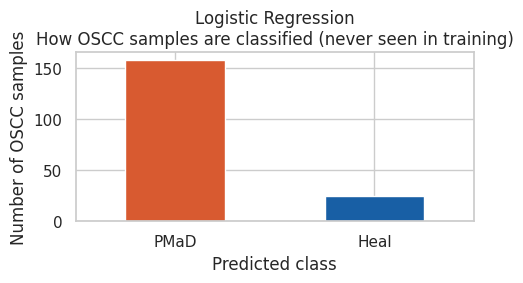


  Random Forest
  OSCC samples predicted as PMaD : 112/183 (61.2%)
  OSCC samples predicted as Heal : 71/183 (38.8%)


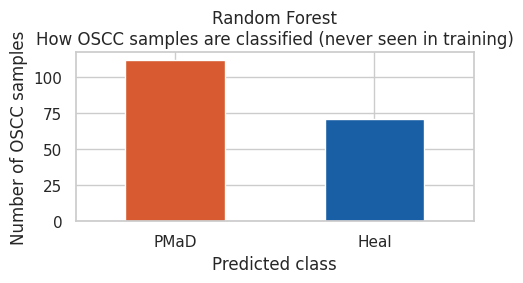


  XGBoost
  OSCC samples predicted as PMaD : 118/183 (64.5%)
  OSCC samples predicted as Heal : 65/183 (35.5%)


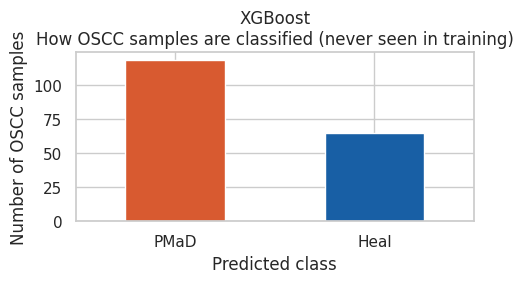

In [ ]:
# ── 3. Predict on OSCC samples ──────────────────────────────
models_exp2 = {
    "Logistic Regression": (lr_exp2,  X_oscc,     ["Heal", "PMaD"]),
    "Random Forest":       (rf_exp2,  X_oscc,     ["Heal", "PMaD"]),
    "XGBoost":             (xgb_exp2, X_oscc_xgb, le_exp2.classes_),
}

for model_name, (model, X_input, classes) in models_exp2.items():

    if model_name == "XGBoost":
        preds_enc = model.predict(X_input)
        preds = le_exp2.inverse_transform(preds_enc)
    else:
        preds = model.predict(X_input)

    counts = pd.Series(preds).value_counts()
    total  = len(preds)
    pmad_n = counts.get("PMaD", 0)
    heal_n = counts.get("Heal", 0)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  OSCC samples predicted as PMaD : {pmad_n}/{total} ({pmad_n/total*100:.1f}%)")
    print(f"  OSCC samples predicted as Heal : {heal_n}/{total} ({heal_n/total*100:.1f}%)")

    # bar chart
    fig, ax = plt.subplots(figsize=(5, 3))
    counts.plot(kind="bar", color=["#D85A30", "#185FA5"], ax=ax)
    ax.set_title(f"{model_name}\nHow OSCC samples are classified (never seen in training)")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Number of OSCC samples")
    ax.set_xticklabels(counts.index, rotation=0)
    plt.tight_layout()
    plt.show()

Exmperiment w SMOTE

In [ ]:
# ── 2. Train all three models on Heal + PMaD only ───────────

# ============================================================
# EXPERIMENT 2 — CELL 2: Grid search with PMaD recall scorer
# + SMOTE oversampling
# ============================================================


# custom scorer — optimise specifically for PMaD recall
pmad_recall_scorer = make_scorer(
    recall_score,
    labels=["PMaD"],
    average="macro"
)

# for XGBoost we need integer labels so use index of PMaD
pmad_idx = list(le_exp2.classes_).index("PMaD")
pmad_recall_scorer_enc = make_scorer(
    recall_score,
    labels=[pmad_idx],
    average="macro"
)

cv_exp2 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# ── Logistic Regression ─────────────────────────────────────
lr_pipe_exp2 = ImbPipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=4)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])

lr_grid_exp2 = GridSearchCV(
    lr_pipe_exp2,
    param_grid={"clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=cv_exp2,
    scoring=pmad_recall_scorer,
    n_jobs=-1,
    verbose=1
)
lr_grid_exp2.fit(X_train_exp2, y_train_exp2)
print("Best LR C:", lr_grid_exp2.best_params_)
print("Best LR PMaD recall:", lr_grid_exp2.best_score_)

# ── Random Forest ───────────────────────────────────────────
rf_pipe_exp2 = ImbPipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=4)),
    ("clf", RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_grid_exp2 = GridSearchCV(
    rf_pipe_exp2,
    param_grid={
        "clf__n_estimators":     [200, 300, 500],
        "clf__max_features":     ["sqrt", "log2"],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_depth":        [None, 5, 10]
    },
    cv=cv_exp2,
    scoring=pmad_recall_scorer,
    n_jobs=-1,
    verbose=1
)
rf_grid_exp2.fit(X_train_exp2, y_train_exp2)
print("Best RF params:", rf_grid_exp2.best_params_)
print("Best RF PMaD recall:", rf_grid_exp2.best_score_)

# ── XGBoost ─────────────────────────────────────────────────
xgb_pipe_exp2 = ImbPipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=4)),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_grid_exp2 = GridSearchCV(
    xgb_pipe_exp2,
    param_grid={
        "clf__n_estimators":      [200, 300, 500],
        "clf__learning_rate":     [0.01, 0.05, 0.1],
        "clf__max_depth":         [3, 4, 6],
        "clf__subsample":         [0.7, 0.8, 1.0],
        "clf__colsample_bytree":  [0.7, 0.8, 1.0]
    },
    cv=cv_exp2,
    scoring=pmad_recall_scorer_enc,
    n_jobs=-1,
    verbose=1
)
xgb_grid_exp2.fit(X_train_exp2_xgb, y_train_exp2_enc)
print("Best XGBoost params:", xgb_grid_exp2.best_params_)
print("Best XGBoost PMaD recall:", xgb_grid_exp2.best_score_)

Fitting 15 folds for each of 5 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


Best LR C: {'clf__C': 0.001}
Best LR PMaD recall: nan
Fitting 15 folds for each of 54 candidates, totalling 810 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best RF params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Best RF PMaD recall: nan
Fitting 15 folds for each of 243 candidates, totalling 3645 fits
Best XGBoost params: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.7}
Best XGBoost PMaD recall: 0.6888888888888888



  Logistic Regression
  OSCC predicted as PMaD : 146/183 (79.8%)
  OSCC predicted as Heal : 37/183 (20.2%)


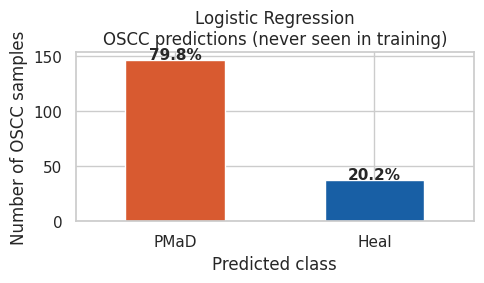


  Random Forest
  OSCC predicted as PMaD : 117/183 (63.9%)
  OSCC predicted as Heal : 66/183 (36.1%)


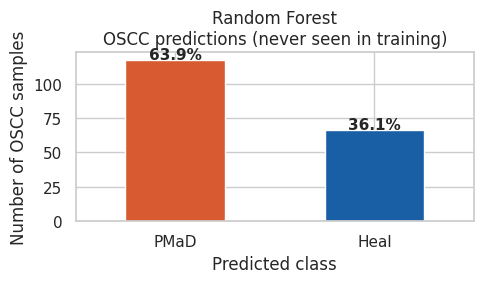


  XGBoost
  OSCC predicted as PMaD : 106/183 (57.9%)
  OSCC predicted as Heal : 77/183 (42.1%)


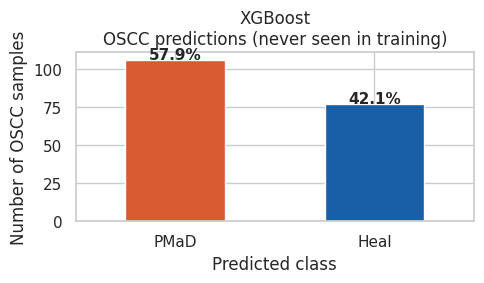


=== Experiment 2 Summary ===
              Model  PMaD (n)  Heal (n) PMaD (%) Heal (%)
Logistic Regression       146        37    79.8%    20.2%
      Random Forest       117        66    63.9%    36.1%
            XGBoost       106        77    57.9%    42.1%


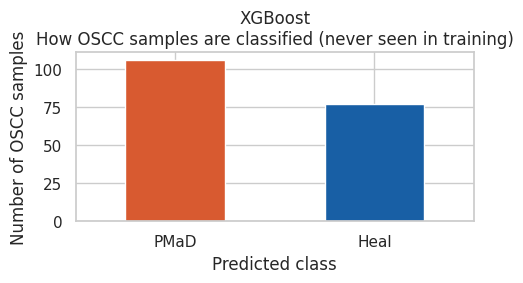

In [ ]:
# ── 3. Predict on OSCC samples ──────────────────────────────# ============================================================
# EXPERIMENT 2 — CELL 3: Predict on OSCC + visualise
# ============================================================

models_exp2 = {
    "Logistic Regression": (lr_grid_exp2.best_estimator_,  X_oscc,     None),
    "Random Forest":       (rf_grid_exp2.best_estimator_,  X_oscc,     None),
    "XGBoost":             (xgb_grid_exp2.best_estimator_, X_oscc_xgb, le_exp2),
}

all_exp2_results = []

for model_name, (model, X_input, le) in models_exp2.items():

    preds = model.predict(X_input)

    # decode XGBoost predictions back to string labels
    if le is not None:
        preds = le.inverse_transform(preds)

    counts  = pd.Series(preds).value_counts()
    total   = len(preds)
    pmad_n  = counts.get("PMaD", 0)
    heal_n  = counts.get("Heal", 0)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  OSCC predicted as PMaD : {pmad_n}/{total} ({pmad_n/total*100:.1f}%)")
    print(f"  OSCC predicted as Heal : {heal_n}/{total} ({heal_n/total*100:.1f}%)")

    all_exp2_results.append({
        "Model":   model_name,
        "PMaD (n)": pmad_n,
        "Heal (n)": heal_n,
        "PMaD (%)": f"{pmad_n/total*100:.1f}%",
        "Heal (%)": f"{heal_n/total*100:.1f}%"
    })

    # bar chart
    fig, ax = plt.subplots(figsize=(5, 3))
    pd.Series({"PMaD": pmad_n, "Heal": heal_n}).plot(
        kind="bar",
        color=["#D85A30", "#185FA5"],
        ax=ax
    )
    ax.set_title(f"{model_name}\nOSCC predictions (never seen in training)")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Number of OSCC samples")
    ax.set_xticklabels(["PMaD", "Heal"], rotation=0)
    for i, v in enumerate([pmad_n, heal_n]):
        ax.text(i, v + 1, f"{v/total*100:.1f}%",
                ha="center", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

# summary table
print("\n=== Experiment 2 Summary ===")
print(pd.DataFrame(all_exp2_results).to_string(index=False))

# bar chart
fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind="bar", color=["#D85A30", "#185FA5"], ax=ax)
ax.set_title(f"{model_name}\nHow OSCC samples are classified (never seen in training)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Number of OSCC samples")
ax.set_xticklabels(counts.index, rotation=0)
plt.tight_layout()
plt.show()